# QF 627 Programming and Computational Finance
## Lesson 04 | A Gentle Introduction to Quantitative Trading Strategies and Backtesting

> Hi Team 👋

> Thank you for opening the script 🙂 As we discussed, to maximize your learning, instead of covering each week’s lecture note in just one week, we will now be discussing each script over the course of two weeks.

> Today, we’ll begin exploring your first algorithmic trading strategy. Next week, we’ll continue building on that foundation. In the meantime, I encourage you to revisit the content and experiment with the code included in the script as a preview of the learning to come.

## DEPENDENCIES

In [1]:
# Load libraries.

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

import seaborn as sns

import time

import datetime as dt
import re

import warnings
warnings.filterwarnings("ignore")

# Setting baseline seed
np.random.seed(2025)

# Set print options.

np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

%matplotlib inline

# Define our customized timer function

def countdown(Time):
    
    while Time:
        minutes, seconds = divmod(Time, 60)
        timer = "{:02d}:{:02d}".format(minutes, seconds)
        
        print(timer, end = "\r")
        time.sleep(1)
        Time -= 1
        
    print("Let us solve the problem above together :)")

In [2]:
%whos

Variable    Type        Data/Info
---------------------------------
countdown   function    <function countdown at 0x123615300>
dt          module      <module 'datetime' from '<...>/python3.12/datetime.py'>
mpl         module      <module 'matplotlib' from<...>/matplotlib/__init__.py'>
np          module      Shape: <function shape at 0x1044cd080>
pd          module      <module 'pandas' from '/U<...>ages/pandas/__init__.py'>
plt         module      <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
re          module      <module 're' from '/Libra<...>thon3.12/re/__init__.py'>
sns         module      <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>
time        module      <module 'time' (built-in)>
warnings    module      <module 'warnings' from '<...>/python3.12/warnings.py'>


In [3]:
countdown(1)

Let us solve the problem above together :)


## 👉 <a id = "top">Learning Pointers</a> 👈 

## [1. Rolling Statistics Revisited](#p1)

> ### <font color = red> Rolling Statistics </font>

## [2. Building Simple Momentum Trading Strategy](#p2)

> ### <font color = red> SMA </font>

## [3. Backtesting Trading Strategy](#p3)

> ### <font color = red> Backtesting is NOT Forecasting </font>

## [4. Performance Metrics](#p4)

> ### <font color = red> Sharpe, MDD, & CAGR </font>

## [5. What We Learned](#p5)

> ### <font color = red> Thus far... </font>

## <a id = "p1">1. </a> <font color = "green"> Rolling Statistics </font>  [back to table of contents](#top)

### Install new library for extracting financial market data from Yahoo Finance

In [4]:
# !pip install yfinance==0.2.58

<mark>Workflow</mark>

- Define
- `Collect`

In [5]:
countdown(5)

Let us solve the problem above together :)


In [6]:
%who

countdown	 dt	 mpl	 np	 pd	 plt	 re	 sns	 time	 
warnings	 


In [7]:
import yfinance as yf

In [8]:
%whos

Variable    Type        Data/Info
---------------------------------
countdown   function    <function countdown at 0x123615300>
dt          module      <module 'datetime' from '<...>/python3.12/datetime.py'>
mpl         module      <module 'matplotlib' from<...>/matplotlib/__init__.py'>
np          module      Shape: <function shape at 0x1044cd080>
pd          module      <module 'pandas' from '/U<...>ages/pandas/__init__.py'>
plt         module      <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
re          module      <module 're' from '/Libra<...>thon3.12/re/__init__.py'>
sns         module      <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>
time        module      <module 'time' (built-in)>
warnings    module      <module 'warnings' from '<...>/python3.12/warnings.py'>
yf          module      <module 'yfinance' from '<...>es/yfinance/__init__.py'>


In [9]:
yf.__version__

'0.2.65'

### COLLECT & IMPORT data from Yahoo!Finance

In [10]:
starting = "2025-01-01"
ending = "2025-05-06"

In [11]:
nvda =\
( # one ticker
    yf
    .download("NVDA", # ticker
              start = "2025-01-01", # starting date
              end = "2025-05-06") # ending date
    # .droplevel("Ticker",
    #            axis = 1)
    # [["Close", "Volume"]]
)

[*********************100%***********************]  1 of 1 completed


In [12]:
nvda

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2025-01-02,138.279877,138.849760,134.600685,135.970382,198247200
2025-01-03,144.438538,144.868437,139.699564,139.979502,229322500
2025-01-06,149.397446,152.126862,147.787811,148.557632,265377400
2025-01-07,140.109467,153.096642,139.979490,152.996658,351782200
2025-01-08,140.079483,143.918643,137.530035,142.548946,227349900
...,...,...,...,...,...
2025-04-29,109.006279,110.186131,107.426484,107.656450,170444300
2025-04-30,108.906296,108.906296,104.066908,104.456859,235044600


In [13]:
(
    nvda
    .droplevel("Ticker",
               axis = 1)
)

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-01-02,138.279877,138.849760,134.600685,135.970382,198247200
2025-01-03,144.438538,144.868437,139.699564,139.979502,229322500
2025-01-06,149.397446,152.126862,147.787811,148.557632,265377400
2025-01-07,140.109467,153.096642,139.979490,152.996658,351782200
2025-01-08,140.079483,143.918643,137.530035,142.548946,227349900
...,...,...,...,...,...
2025-04-29,109.006279,110.186131,107.426484,107.656450,170444300
2025-04-30,108.906296,108.906296,104.066908,104.456859,235044600
2025-05-01,111.595955,114.925538,111.285996,113.065771,236121500


In [14]:
nvda.columns

MultiIndex([( 'Close', 'NVDA'),
            (  'High', 'NVDA'),
            (   'Low', 'NVDA'),
            (  'Open', 'NVDA'),
            ('Volume', 'NVDA')],
           names=['Price', 'Ticker'])

In [15]:
nvda[["Close"]]

Price,Close
Ticker,NVDA
Date,
2025-01-02,138.279877
2025-01-03,144.438538
2025-01-06,149.397446
2025-01-07,140.109467
2025-01-08,140.079483
...,...
2025-04-29,109.006279
2025-04-30,108.906296


In [16]:
nvda["Close"]

Ticker,NVDA
Date,
2025-01-02,138.279877
2025-01-03,144.438538
2025-01-06,149.397446
2025-01-07,140.109467
2025-01-08,140.079483
...,...
2025-04-29,109.006279
2025-04-30,108.906296
2025-05-01,111.595955


In [17]:
MAANG =\
    ["META",
     "AAPL",
     "AMZN",
     "NFLX",
     "GOOG"]

In [18]:
maang_prices =\
(
    yf
    .download(MAANG,
              start = starting,
              end = ending)
    ["Close"]
)

[*********************100%***********************]  5 of 5 completed


In [19]:
maang_prices

Ticker,AAPL,AMZN,GOOG,META,NFLX
Date,,,,,
2025-01-02,242.987427,220.220001,190.014633,597.843506,886.729980
2025-01-03,242.499146,224.190002,192.506577,603.220947,881.049988
2025-01-06,244.133347,227.610001,197.320984,628.731384,881.789978
2025-01-07,241.353226,222.110001,196.075012,616.450073,879.190002
2025-01-08,241.841476,222.130005,194.759277,609.296753,875.000000
...,...,...,...,...,...
2025-04-29,210.694290,187.389999,161.720886,553.640076,1125.640015
2025-04-30,211.981125,184.419998,160.553329,548.207886,1131.719971
2025-05-01,212.799133,190.199997,162.449356,571.384460,1133.469971


In [20]:
## Extracting date for two symbols
two_symbols_meta_msft =\
(
    yf
    .download(["META", "MSFT"],
              start = starting,
              end = ending 
             )
    ["Close"]
)

[*********************100%***********************]  2 of 2 completed


In [21]:
two_symbols_meta_msft.columns

Index(['META', 'MSFT'], dtype='object', name='Ticker')

In [22]:
two_symbols_meta_msft

Ticker,META,MSFT
Date,,
2025-01-02,597.843506,416.292511
2025-01-03,603.220947,421.036469
2025-01-06,628.731384,425.511871
2025-01-07,616.450073,420.061798
2025-01-08,609.296753,422.239838
...,...,...
2025-04-29,553.640076,392.672424
2025-04-30,548.207886,393.888184
2025-05-01,571.384460,423.923553


### Analytics Contexts


> `Rolling statistics` are useful in the `technical analysis` of stocks. Their use can be compared to `fundamental analysis`, which focuses on financial reports and the strategic positions of the company whose stock is being examined.

> The use of `two simple moving averages` (SMAs) is a basic trading strategy based on technical analysis.

•	A trader should go `long` on a stock (or any financial instrument in general) when its `shorter-term SMA is above its longer-term SMA`, and should go short when the opposite holds true.

•	This concept can easily be implemented with `pandas`, thanks to the `DataFrame object`.

> Rolling statistics are generally used only when there is enough data, given the window parameter specification.

#### Let's calculate the values for the shorter-term and longer-term SMAs.

> Then visualize the stock price data, along with the two SMA time series.

In [23]:
%whos

Variable                Type         Data/Info
----------------------------------------------
MAANG                   list         n=5
countdown               function     <function countdown at 0x123615300>
dt                      module       <module 'datetime' from '<...>/python3.12/datetime.py'>
ending                  str          2025-05-06
maang_prices            DataFrame    Shape: (84, 5)
mpl                     module       <module 'matplotlib' from<...>/matplotlib/__init__.py'>
np                      module       Shape: <function shape at 0x1044cd080>
nvda                    DataFrame    Shape: (84, 5)
pd                      module       <module 'pandas' from '/U<...>ages/pandas/__init__.py'>
plt                     module       <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
re                      module       <module 're' from '/Libra<...>thon3.12/re/__init__.py'>
sns                     module       <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>
starti

In [24]:
maang_prices

Ticker,AAPL,AMZN,GOOG,META,NFLX
Date,,,,,
2025-01-02,242.987427,220.220001,190.014633,597.843506,886.729980
2025-01-03,242.499146,224.190002,192.506577,603.220947,881.049988
2025-01-06,244.133347,227.610001,197.320984,628.731384,881.789978
2025-01-07,241.353226,222.110001,196.075012,616.450073,879.190002
2025-01-08,241.841476,222.130005,194.759277,609.296753,875.000000
...,...,...,...,...,...
2025-04-29,210.694290,187.389999,161.720886,553.640076,1125.640015
2025-04-30,211.981125,184.419998,160.553329,548.207886,1131.719971
2025-05-01,212.799133,190.199997,162.449356,571.384460,1133.469971


```python
# Moving Average Calculation
DF["ma_NofDays"] =\
(
    DF
    ["price"]
    .rolling(window = 22) # rolling 22 days --> 22 trading days ==> about a month
    .mean() # rolling averages with 22 days of windows
)

In [25]:
apple_prices =\
(
    maang_prices
    [["AAPL"]]
)

In [26]:
apple_prices

Ticker,AAPL
Date,
2025-01-02,242.987427
2025-01-03,242.499146
2025-01-06,244.133347
2025-01-07,241.353226
2025-01-08,241.841476
...,...
2025-04-29,210.694290
2025-04-30,211.981125
2025-05-01,212.799133


In [27]:
apple_prices["ma_5"] =\
(
    apple_prices
    ["AAPL"]
    .rolling(window = 5) # 5 day MA --> one week of trading window
    .mean()
)

In [28]:
apple_prices.head(15)

Ticker,AAPL,ma_5
Date,,
2025-01-02,242.987427,NaN
2025-01-03,242.499146,NaN
2025-01-06,244.133347,NaN
2025-01-07,241.353226,NaN
2025-01-08,241.841476,242.562924
2025-01-10,236.012177,241.167874
2025-01-13,233.570847,239.382214
2025-01-14,232.454803,237.046506
2025-01-15,237.028564,236.181573


In [29]:
apple_prices["ma_22"] =\
(
    apple_prices
    ["AAPL"]
    .rolling(window = 22) # 22 day MA --> one MONTH of trading window
    .mean()
)

In [30]:
apple_prices.iloc[ :22]

Ticker,AAPL,ma_5,ma_22
Date,,,
2025-01-02,242.987427,NaN,NaN
2025-01-03,242.499146,NaN,NaN
2025-01-06,244.133347,NaN,NaN
2025-01-07,241.353226,NaN,NaN
2025-01-08,241.841476,242.562924,NaN
2025-01-10,236.012177,241.167874,NaN
2025-01-13,233.570847,239.382214,NaN
2025-01-14,232.454803,237.046506,NaN
2025-01-15,237.028564,236.181573,NaN


In [31]:
### APPLE stock price
### past 12 years

aapl =\
(
    yf
    .download("AAPL",
              start = "2013-05-07",
              end = "2025-05-06")
    .droplevel("Ticker",
               axis = 1)
    [["Close"]]
)

[*********************100%***********************]  1 of 1 completed


In [32]:
aapl

Price,Close
Date,
2013-05-07,13.972260
2013-05-08,14.130061
2013-05-09,14.006787
2013-05-10,13.890261
2013-05-13,13.944540
...,...
2025-04-29,210.694290
2025-04-30,211.981125
2025-05-01,212.799133


In [33]:
### Noise-reduced MAs 

### Shorter-term --> 22 days
### Longer-term --> 250 days

aapl["ma_22"] =\
(
    aapl
    ["Close"]
    .rolling(window = 22)
    .mean()
)

aapl["ma_250"] =\
(
    aapl
    ["Close"]
    .rolling(window = 250)
    .mean()
)

In [34]:
aapl

Price,Close,ma_22,ma_250
Date,,,
2013-05-07,13.972260,NaN,NaN
2013-05-08,14.130061,NaN,NaN
2013-05-09,14.006787,NaN,NaN
2013-05-10,13.890261,NaN,NaN
2013-05-13,13.944540,NaN,NaN
...,...,...,...
2025-04-29,210.694290,201.887197,220.969938
2025-04-30,211.981125,201.642342,221.141401
2025-05-01,212.799133,201.242865,221.320226


In [35]:
%whos

Variable                Type         Data/Info
----------------------------------------------
MAANG                   list         n=5
aapl                    DataFrame    Shape: (3018, 3)
apple_prices            DataFrame    Shape: (84, 3)
countdown               function     <function countdown at 0x123615300>
dt                      module       <module 'datetime' from '<...>/python3.12/datetime.py'>
ending                  str          2025-05-06
maang_prices            DataFrame    Shape: (84, 5)
mpl                     module       <module 'matplotlib' from<...>/matplotlib/__init__.py'>
np                      module       Shape: <function shape at 0x1044cd080>
nvda                    DataFrame    Shape: (84, 5)
pd                      module       <module 'pandas' from '/U<...>ages/pandas/__init__.py'>
plt                     module       <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
re                      module       <module 're' from '/Libra<...>thon3.12/re/__init_

In [36]:
### Write your code like Pythonista

permutation_of_windows = [12, 22, 48, 56, 120, 220, 250] # hyper-parameter to tune for optimization

In [37]:
aapl.head(3)

Price,Close,ma_22,ma_250
Date,,,
2013-05-07,13.972260,NaN,NaN
2013-05-08,14.130061,NaN,NaN
2013-05-09,14.006787,NaN,NaN


In [38]:
for i in permutation_of_windows:
    aapl[f"sma_{i}"] =\
    (
        aapl
        ["Close"]
        .rolling(window = i)
        .mean()
    )

In [39]:
aapl

Price,Close,ma_22,ma_250,sma_12,sma_22,sma_48,sma_56,sma_120,sma_220,sma_250
Date,,,,,,,,,,
2013-05-07,13.972260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-05-08,14.130061,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-05-09,14.006787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-05-10,13.890261,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-05-13,13.944540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2025-04-29,210.694290,201.887197,220.969938,202.052096,201.887197,216.015833,219.001975,228.306057,225.602458,220.969938
2025-04-30,211.981125,201.642342,221.141401,203.245010,201.642342,215.323153,218.736910,228.231053,225.603109,221.141401
2025-05-01,212.799133,201.242865,221.320226,204.142813,201.242865,214.653335,218.481642,228.150922,225.602192,221.320226


> Here, the SMAs can be used to generate positions to implement a trading strategy.

> Building a trading strategy will be discussed below. But here, let’s visualize a long position by a value of 1 and a short position by a value of –1.

> The change in the position can be visually detected, when the two lines representing the SMA time series cross.

## <a id = "p2">2.</a>  <font color = "green"> Simple Momentum Trading Strategy </font>  [back to table of contents](#top)

<a id="trading"></a>
### A Gentle Introduction to Stock Trading Strategies: A Simple Momentum Trading Strategy

> Now, we will discuss the development of a simple `momentum` strategy. We’ll go through that development step by step, firstly by formulating and programming a simple algorithmic trading strategy. We’ll then backtest our strategy, assessing its performance with the `pandas` library.

> Building a trading strategy requires multiple stages of work. As you will see later in our course, when you learn about machine learning (no pun intended here), building a trading strategy is an iterative process of training, tuning, optimizing, and assessing the performance of your model.

> As a starting point in learning about stock trading strategies, you will learn momentum strategy (a.k.a. divergence or trend trading). This strategy is based on a theory that movement of a quantity will continue in its current direction. Thus, stocks have momentum, or upward or downward trends, and you can detect and exploit those trends.

#### A moving average crossover and a dual moving average crossover are examples of the momentum strategy.

- The `moving average crossover` is when the price of an asset moves from one side of a moving average to the other. This `crossover` denotes a `change in momentum`, and can be used as the point at which to make the decision to `enter or exit` the market.

<br>

- A `dual moving average crossover` occurs when a short-term average crosses a long-term average. This signal is taken as identifying that momentum is shifting in the direction of the short-term average. A `buy signal` is when the short-term average crosses the long-term average and scores above it. A `sell signal` is presented by a short-term average crossing a long-term average and falling below it.

> Here, when you go long, you think that the stock price will go up and will sell at a higher price in the future (buy signal)

> When you go short, you sell your stock, expecting to be able to buy it back at a lower price and realize a profit (sell signal).

> Below, we will go through the strategy building step by step.

In [40]:
%whos

Variable                 Type         Data/Info
-----------------------------------------------
MAANG                    list         n=5
aapl                     DataFrame    Shape: (3018, 10)
apple_prices             DataFrame    Shape: (84, 3)
countdown                function     <function countdown at 0x123615300>
dt                       module       <module 'datetime' from '<...>/python3.12/datetime.py'>
ending                   str          2025-05-06
i                        int          250
maang_prices             DataFrame    Shape: (84, 5)
mpl                      module       <module 'matplotlib' from<...>/matplotlib/__init__.py'>
np                       module       Shape: <function shape at 0x1044cd080>
nvda                     DataFrame    Shape: (84, 5)
pd                       module       <module 'pandas' from '/U<...>ages/pandas/__init__.py'>
permutation_of_windows   list         n=7
plt                      module       <module 'matplotlib.pyplo<...>es/matplotlib

# 5 Strategy vectors
1. Prices
2. Noise reduction
    - e.g. Moving Averages
3. Signal
    - RSI
    - MACD
4. Position
    - buy
    - sell
    - short sell
    - hold
5. P&L
    - total return index

## types of systematic trading examples
1. mean reversion
2. trend following

#### Step 1: `Define` two lookback periods, of `short` and `long` duration

> Here we will create two variables and assign one integer per variable.

> It is obvious, but make sure that the integer you assign to the short window is shorter than the integer you assign to the long window variable 🙂

In [41]:
short = 22 # this is a NOT fixated value
long = 84

In [42]:
short_long_periods = [10, 22, 64, 84, 120, 250]

In [43]:
import yfinance as yf

In [44]:
yf.__version__

'0.2.65'

In [45]:
nvda =\
(
    yf
    .download(["NVDA"],
              start = dt.datetime(2014, 5, 8),
              end = dt.datetime(2024, 5, 7)
             )
    ["Close"]
)

nvda

[*********************100%***********************]  1 of 1 completed


Ticker,NVDA
Date,
2014-05-08,0.438089
2014-05-09,0.427433
2014-05-12,0.439984
2014-05-13,0.432880
2014-05-14,0.428617
...,...
2024-04-30,86.362755
2024-05-01,83.003265
2024-05-02,85.778015


#### Step 2: Create an empty signals DataFrame

> Make sure to copy the index of your stock data so that we can start calculating the daily `buy or sell` signal 👀 

In [46]:
BUY_or_SELL =\
(
    pd
    .DataFrame(index = nvda.index) # investment universe
)

In [47]:
BUY_or_SELL

""
Date
2014-05-08
2014-05-09
2014-05-12
2014-05-13
2014-05-14
...
2024-04-30
2024-05-01
2024-05-02


> You might want to make a column named `BUY_or_SELL` in your empty DataFrame, and set the value for all rows in that column to 0.0.

In [48]:
BUY_or_SELL["BUY_or_SELL"] = 0.0
BUY_or_SELL

,BUY_or_SELL
Date,
2014-05-08,0.0
2014-05-09,0.0
2014-05-12,0.0
2014-05-13,0.0
2014-05-14,0.0
...,...
2024-04-30,0.0
2024-05-01,0.0
2024-05-02,0.0


> Steps 1 and 2 above set the stage for our main work.

#### Step 3: Assign the set of short and long SMAs (over the respective short and long time windows)

In [49]:
BUY_or_SELL.rolling?

Signature:
BUY_or_SELL.rolling(
    window: 'int | dt.timedelta | str | BaseOffset | BaseIndexer',
    min_periods: 'int | None' = None,
    center: 'bool_t' = False,
    win_type: 'str | None' = None,
    on: 'str | None' = None,
    axis: 'Axis | lib.NoDefault' = <no_default>,
    closed: 'IntervalClosedType | None' = None,
    step: 'int | None' = None,
    method: 'str' = 'single',
) -> 'Window | Rolling'
Docstring:
Provide rolling window calculations.

Parameters
----------
window : int, timedelta, str, offset, or BaseIndexer subclass
    Size of the moving window.

    If an integer, the fixed number of observations used for
    each window.

    If a timedelta, str, or offset, the time period of each window. Each
    window will be a variable sized based on the observations included in
    the time-period. This is only valid for datetimelike indexes.
    To learn more about the offsets & frequency strings, please see `this link
    <https://pandas.pydata.org/pandas-docs/stable/u

> Here, please use the function `rolling()` to initiate your rolling window calculations. 

> Specifically, you will set the following three arguments.

* `window` 
* `min_period`
* `center`  

> Input either SHORT or LONG, with `1` as the minimum number of data points in the window that are required to have a value, and False, so that the labels are not set at the center of the window.

> Here, don’t forget to chain the function `mean()` so that we can calculate the rolling mean.

```python
moving_averages["ma_"] =\
(
    DF
    ["instrument"]
    .rolling(window = int # ,
            # min_periods = int,
            # center = bool
            )
    .mean()
)
```

In [50]:
nvda.columns

Index(['NVDA'], dtype='object', name='Ticker')

In [51]:
help(nvda.rename)

Help on method rename in module pandas.core.frame:

rename(mapper: 'Renamer | None' = None, *, index: 'Renamer | None' = None, columns: 'Renamer | None' = None, axis: 'Axis | None' = None, copy: 'bool | None' = None, inplace: 'bool' = False, level: 'Level | None' = None, errors: 'IgnoreRaise' = 'ignore') -> 'DataFrame | None' method of pandas.core.frame.DataFrame instance
    Rename columns or index labels.

    Function / dict values must be unique (1-to-1). Labels not contained in
    a dict / Series will be left as-is. Extra labels listed don't throw an
    error.

    See the :ref:`user guide <basics.rename>` for more.

    Parameters
    ----------
    mapper : dict-like or function
        Dict-like or function transformations to apply to
        that axis' values. Use either ``mapper`` and ``axis`` to
        specify the axis to target with ``mapper``, or ``index`` and
        ``columns``.
    index : dict-like or function
        Alternative to specifying axis (``mapper, axis=0

In [52]:
nvda =\
(
    nvda              # "old": "new"  
    .rename(columns = {"NVDA": "price"}
           )
)

In [53]:
nvda

Ticker,price
Date,
2014-05-08,0.438089
2014-05-09,0.427433
2014-05-12,0.439984
2014-05-13,0.432880
2014-05-14,0.428617
...,...
2024-04-30,86.362755
2024-05-01,83.003265
2024-05-02,85.778015


In [54]:
%whos

Variable                 Type         Data/Info
-----------------------------------------------
BUY_or_SELL              DataFrame    Shape: (2516, 1)
MAANG                    list         n=5
aapl                     DataFrame    Shape: (3018, 10)
apple_prices             DataFrame    Shape: (84, 3)
countdown                function     <function countdown at 0x123615300>
dt                       module       <module 'datetime' from '<...>/python3.12/datetime.py'>
ending                   str          2025-05-06
i                        int          250
long                     int          84
maang_prices             DataFrame    Shape: (84, 5)
mpl                      module       <module 'matplotlib' from<...>/matplotlib/__init__.py'>
np                       module       Shape: <function shape at 0x1044cd080>
nvda                     DataFrame    Shape: (2516, 1)
pd                       module       <module 'pandas' from '/U<...>ages/pandas/__init__.py'>
permutation_of_windows   

> Now you have calculated the mean average of the short and long windows.

In [55]:
short

22

In [56]:
### Shorter-term simple moving averages

BUY_or_SELL["shorter_SMA"] =\
(                 # EWMA
    nvda
    ["price"]
    .rolling(window = short,
             min_periods = 1, # there will be no missing values for moving averages
             center = False)
    .mean()
)

In [57]:
BUY_or_SELL.head(3)

,BUY_or_SELL,shorter_SMA
Date,,
2014-05-08,0.0,0.438089
2014-05-09,0.0,0.432761
2014-05-12,0.0,0.435169


In [58]:
%who

BUY_or_SELL	 MAANG	 aapl	 apple_prices	 countdown	 dt	 ending	 i	 long	 
maang_prices	 mpl	 np	 nvda	 pd	 permutation_of_windows	 plt	 re	 short	 
short_long_periods	 sns	 starting	 time	 two_symbols_meta_msft	 warnings	 yf	 


In [59]:
long

84

In [60]:
short_long_periods

[10, 22, 64, 84, 120, 250]

In [61]:
# BUY_or_SELL["SMA_120"] =\
# (
#     nvda
#     ["price"]
#     .rolling(window = 120)
#     .mean()
# )

In [62]:
# BUY_or_SELL["SMA_250"] =\
# (
#     nvda
#     ["price"]
#     .rolling(window = 250)
#     .mean()
# )

In [63]:
# Pythonian-way of assigning various sma calculations

for i in short_long_periods:
    BUY_or_SELL[f"SMA_{i}"] =\
    (
        nvda
        ["price"]
        .rolling(window = i,
                 min_periods = 1)
        .mean()
    )

In [64]:
BUY_or_SELL

,BUY_or_SELL,shorter_SMA,SMA_10,SMA_22,SMA_64,SMA_84,SMA_120,SMA_250
Date,,,,,,,,
2014-05-08,0.0,0.438089,0.438089,0.438089,0.438089,0.438089,0.438089,0.438089
2014-05-09,0.0,0.432761,0.432761,0.432761,0.432761,0.432761,0.432761,0.432761
2014-05-12,0.0,0.435169,0.435169,0.435169,0.435169,0.435169,0.435169,0.435169
2014-05-13,0.0,0.434597,0.434597,0.434597,0.434597,0.434597,0.434597,0.434597
2014-05-14,0.0,0.433401,0.433401,0.433401,0.433401,0.433401,0.433401,0.433401
...,...,...,...,...,...,...,...,...
2024-04-30,0.0,85.664976,83.067249,85.664976,81.987196,75.634403,67.381690,54.107408
2024-05-01,0.0,85.332308,82.967894,85.332308,82.303769,76.033285,67.690651,54.328299
2024-05-02,0.0,85.167156,83.082442,85.167156,82.683173,76.481311,68.017580,54.561249


In [65]:
## Longer-term

BUY_or_SELL["longer_SMA"] =\
(
    nvda
    ["price"]
    .rolling(window = long,
             min_periods = 1,
             center = False)
    .mean()
)

BUY_or_SELL.iloc[ :22]

,BUY_or_SELL,shorter_SMA,SMA_10,SMA_22,SMA_64,SMA_84,SMA_120,SMA_250,longer_SMA
Date,,,,,,,,,
2014-05-08,0.0,0.438089,0.438089,0.438089,0.438089,0.438089,0.438089,0.438089,0.438089
2014-05-09,0.0,0.432761,0.432761,0.432761,0.432761,0.432761,0.432761,0.432761,0.432761
2014-05-12,0.0,0.435169,0.435169,0.435169,0.435169,0.435169,0.435169,0.435169,0.435169
2014-05-13,0.0,0.434597,0.434597,0.434597,0.434597,0.434597,0.434597,0.434597,0.434597
2014-05-14,0.0,0.433401,0.433401,0.433401,0.433401,0.433401,0.433401,0.433401,0.433401
2014-05-15,0.0,0.432209,0.432209,0.432209,0.432209,0.432209,0.432209,0.432209,0.432209
2014-05-16,0.0,0.431222,0.431222,0.431222,0.431222,0.431222,0.431222,0.431222,0.431222
2014-05-19,0.0,0.432199,0.432199,0.432199,0.432199,0.432199,0.432199,0.432199,0.432199
2014-05-20,0.0,0.432390,0.432390,0.432390,0.432390,0.432390,0.432390,0.432390,0.432390


#### Step 4: Create a signal when the short moving average crosses the long moving average

> Note that this is only for the period greater than the shortest moving average window. [Recall that this is the step we performed above during our refresher on rolling statistics.](#rolling)

In [66]:
long

84

```python
DF["COLUMN"][how_many_values_from_the_beginning:-how_many_values_from_the_end] # slicing off
```

In [67]:
BUY_or_SELL["BUY_or_SELL"][long: ] =\
( 
    np # if else        # RULE       , True, False
    .where(BUY_or_SELL["shorter_SMA"][long: ] > BUY_or_SELL["longer_SMA"][long: ],
           1.0, 0.0 # team, we are not short-selling when momentum is lost --> pay attention 
           # 1.0 being momentum is activated
           # 0.0 being momentum is lost
           )
)

In [68]:
BUY_or_SELL

,BUY_or_SELL,shorter_SMA,SMA_10,SMA_22,SMA_64,SMA_84,SMA_120,SMA_250,longer_SMA
Date,,,,,,,,,
2014-05-08,0.0,0.438089,0.438089,0.438089,0.438089,0.438089,0.438089,0.438089,0.438089
2014-05-09,0.0,0.432761,0.432761,0.432761,0.432761,0.432761,0.432761,0.432761,0.432761
2014-05-12,0.0,0.435169,0.435169,0.435169,0.435169,0.435169,0.435169,0.435169,0.435169
2014-05-13,0.0,0.434597,0.434597,0.434597,0.434597,0.434597,0.434597,0.434597,0.434597
2014-05-14,0.0,0.433401,0.433401,0.433401,0.433401,0.433401,0.433401,0.433401,0.433401
...,...,...,...,...,...,...,...,...,...
2024-04-30,1.0,85.664976,83.067249,85.664976,81.987196,75.634403,67.381690,54.107408,75.634403
2024-05-01,1.0,85.332308,82.967894,85.332308,82.303769,76.033285,67.690651,54.328299,76.033285
2024-05-02,1.0,85.167156,83.082442,85.167156,82.683173,76.481311,68.017580,54.561249,76.481311


#### Step 5: Calculate the difference between the signals to make trading orders

> We can differentiate between long and short positions, within the column of our DF, where we are `buying` or `selling` stock.

In [69]:
toy_DF =\
(
    pd
    .DataFrame(
        {
            "signal": [0,0,0,1,0,1,1,1,0,1,0]
        }
    )
)

In [ ]:
# 
toy_DF

,signal
0,0
1,0
2,0
3,1
4,0
5,1
6,1
7,1
8,0
9,1


In [71]:
toy_DF["position"] =\
(
    toy_DF
    .diff()
)

In [ ]:
# shift down 1 for tomorrow earnings
# if go long, buy at close, next day position is from yesterday close
toy_DF

,signal,position
0,0,NaN
1,0,0.0
2,0,0.0
3,1,1.0
4,0,-1.0
5,1,1.0
6,1,0.0
7,1,0.0
8,0,-1.0
9,1,1.0


In [73]:
BUY_or_SELL.columns

Index(['BUY_or_SELL', 'shorter_SMA', 'SMA_10', 'SMA_22', 'SMA_64', 'SMA_84',
       'SMA_120', 'SMA_250', 'longer_SMA'],
      dtype='object')

In [74]:
BUY_or_SELL["positions"] =\
(
    BUY_or_SELL["BUY_or_SELL"]
    .diff()
)

BUY_or_SELL[['BUY_or_SELL', 'shorter_SMA', 'longer_SMA', 'positions']]

,BUY_or_SELL,shorter_SMA,longer_SMA,positions
Date,,,,
2014-05-08,0.0,0.438089,0.438089,NaN
2014-05-09,0.0,0.432761,0.432761,0.0
2014-05-12,0.0,0.435169,0.435169,0.0
2014-05-13,0.0,0.434597,0.434597,0.0
2014-05-14,0.0,0.433401,0.433401,0.0
...,...,...,...,...
2024-04-30,1.0,85.664976,75.634403,0.0
2024-05-01,1.0,85.332308,76.033285,0.0
2024-05-02,1.0,85.167156,76.481311,0.0


> Print the signals DataFrame and inspect the results. `Make sure to fully digest what the positions and the signal columns denote in this DF.`

> When you have taken the time to understand the results of the trading strategy, visualize the short and long moving averages, along with the buy and sell signals.

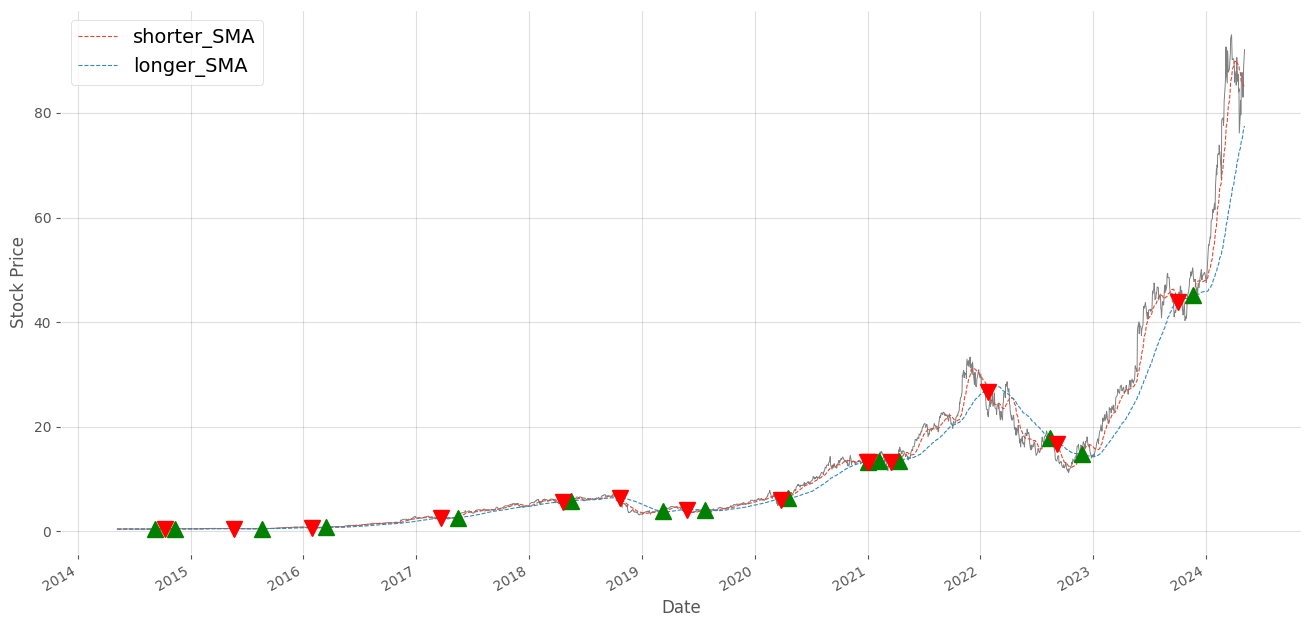

In [75]:
f =\
(
    plt
    .figure(figsize = [16,8]
           )
)

sub=\
(
    f
    .add_subplot(111,
                 ylabel = "Stock Price")
)

# Price Action (Daily)

(
    nvda
    ["price"]
    .plot(ax = sub,
          lw = 0.70,
          color = "grey")
)

# Moving Averages(Shorter vs. Longer)

(
    BUY_or_SELL
    [["shorter_SMA", "longer_SMA"]]
    .plot(ax = sub,
          lw = 0.80,
          style = ["--", "--"]
         )
)

# BUY Signal

(
    sub
    .plot(BUY_or_SELL[BUY_or_SELL.positions == 1.0].index,
          BUY_or_SELL.shorter_SMA[BUY_or_SELL.positions == 1.0],
          "^",
          color = "green",
          markersize = 12)
)

# SELL Signal

(
    sub
    .plot(BUY_or_SELL[BUY_or_SELL.positions == -1.0].index,
          BUY_or_SELL.shorter_SMA[BUY_or_SELL.positions == -1.0],
          "v",
          color = "red",
          markersize = 12)
)

## <a id = "p3">3.</a>  <font color = "green"> Backtesting Trading Strategy </font>  [back to table of contents](#top)

> Now let’s backtest our trading strategy and assess its performance.

#### Elements of Backtesting

- `Data interface` to access your data (here, pandas or pandas-datareader).
- `Strategy` to formulate a signal to go long or short.
- `Portfolio` to generate orders and manage profit and loss (`PnL`).
- `Execution interface` to send orders to the broker and get confirmation that the stock was bought or sold.

> Here, as a starting point in your learning, we will consider the first three items above (but not the execution interface, yet).

> Let’s learn how to create a portfolio which can generate orders and manages the PnL, with yet another `step by step` approach (Yay~) 

#### Step 1: Create a variable (`our_capital`) to set our initial capital, along with a new DataFrame, `our_position`

> We copy the index from another DataFrame.

> This is the signals DataFrame, where we want to consider the period for which we have generated signals.

In [76]:
our_capital = 7e6
our_capital

7000000.0

In [77]:
BUY_or_SELL

,BUY_or_SELL,shorter_SMA,SMA_10,SMA_22,SMA_64,SMA_84,SMA_120,SMA_250,longer_SMA,positions
Date,,,,,,,,,,
2014-05-08,0.0,0.438089,0.438089,0.438089,0.438089,0.438089,0.438089,0.438089,0.438089,NaN
2014-05-09,0.0,0.432761,0.432761,0.432761,0.432761,0.432761,0.432761,0.432761,0.432761,0.0
2014-05-12,0.0,0.435169,0.435169,0.435169,0.435169,0.435169,0.435169,0.435169,0.435169,0.0
2014-05-13,0.0,0.434597,0.434597,0.434597,0.434597,0.434597,0.434597,0.434597,0.434597,0.0
2014-05-14,0.0,0.433401,0.433401,0.433401,0.433401,0.433401,0.433401,0.433401,0.433401,0.0
...,...,...,...,...,...,...,...,...,...,...
2024-04-30,1.0,85.664976,83.067249,85.664976,81.987196,75.634403,67.381690,54.107408,75.634403,0.0
2024-05-01,1.0,85.332308,82.967894,85.332308,82.303769,76.033285,67.690651,54.328299,76.033285,0.0
2024-05-02,1.0,85.167156,83.082442,85.167156,82.683173,76.481311,68.017580,54.561249,76.481311,0.0


In [78]:
our_position =\
(
    pd
    .DataFrame(index = BUY_or_SELL.index)
)

our_position

""
Date
2014-05-08
2014-05-09
2014-05-12
2014-05-13
2014-05-14
...
2024-04-30
2024-05-01
2024-05-02


#### Step 2: Create a new column, NVDA, in `our_position`

> On the days that the `BUY_or_SELL` signal is 1 and the short moving average crosses the long moving average (for the period greater than the shortest moving average window), we’ll buy 200 shares.

> On the days on which the signal is zero, the final result will be zero.

In [79]:
our_position["nvda"] =\
(
    BUY_or_SELL["BUY_or_SELL"]
    .shift(1) # we are buying at the next day's opening price
    * 200
)

our_position

,nvda
Date,
2014-05-08,NaN
2014-05-09,0.0
2014-05-12,0.0
2014-05-13,0.0
2014-05-14,0.0
...,...
2024-04-30,200.0
2024-05-01,200.0
2024-05-02,200.0


#### Step 3: Create a new DF portfolio to store the market value of an open position

In [80]:
toy_DF_for_multiply_method =\
(
    pd
    .DataFrame(
        {"A": [10, 50, 70],
         "B": [1, 5, 7]
        }
    )
)

In [81]:
toy_DF_for_multiply_method

,A,B
0,10,1
1,50,5
2,70,7


In [82]:
sample_nvda =\
(
    nvda
    .reset_index()
    .iloc[ :3]
    [["price"]]
)

In [83]:
sample_nvda

Ticker,price
0,0.438089
1,0.427433
2,0.439984


In [84]:
toy_DF_for_multiply_method

,A,B
0,10,1
1,50,5
2,70,7


In [85]:
sample_nvda

Ticker,price
0,0.438089
1,0.427433
2,0.439984


In [86]:
(
    toy_DF_for_multiply_method
    .multiply(sample_nvda["price"],
              axis = 0)
)

,A,B
0,4.380894,0.438089
1,21.371667,2.137167
2,30.798880,3.079888


In [87]:
portfolio =\
(
    our_position
    .multiply(nvda["price"],
              axis = 0)
)

portfolio

,nvda
Date,
2014-05-08,NaN
2014-05-09,0.000000
2014-05-12,0.000000
2014-05-13,0.000000
2014-05-14,0.000000
...,...
2024-04-30,17272.550964
2024-05-01,16600.653076
2024-05-02,17155.603027


#### Step 4: Create a DF that stores the `difference_in_shares_owned`

In [88]:
difference_in_shares_owned =\
(
    our_position.diff()
)

In [89]:
difference_in_shares_owned

,nvda
Date,
2014-05-08,NaN
2014-05-09,NaN
2014-05-12,0.0
2014-05-13,0.0
2014-05-14,0.0
...,...
2024-04-30,0.0
2024-05-01,0.0
2024-05-02,0.0


#### Step 5: Create a new column, `our_holdings`

> This column will store the value of the positions or shares we have bought, multiplied by the `Adj Close` price.

In [90]:
portfolio["our_holdings"] =\
(
    our_position
    .multiply(nvda["price"],
              axis = 0)
    .sum(axis = 1)
)

portfolio

,nvda,our_holdings
Date,,
2014-05-08,NaN,0.000000
2014-05-09,0.000000,0.000000
2014-05-12,0.000000,0.000000
2014-05-13,0.000000,0.000000
2014-05-14,0.000000,0.000000
...,...,...
2024-04-30,17272.550964,17272.550964
2024-05-01,16600.653076,16600.653076
2024-05-02,17155.603027,17155.603027


#### Step 6: Create a new column, `our_cash`

> This is the capital remaining to spend.

> It can be calculated by taking `our_capital` and subtracting `our_holdings` (the price that we paid when buying stock).

In [91]:
difference_in_shares_owned

,nvda
Date,
2014-05-08,NaN
2014-05-09,NaN
2014-05-12,0.0
2014-05-13,0.0
2014-05-14,0.0
...,...
2024-04-30,0.0
2024-05-01,0.0
2024-05-02,0.0


In [92]:
portfolio["our_cash"] =\
(
    our_capital - (difference_in_shares_owned
                   .multiply(nvda["price"],
                             axis = 0)
                   .sum(axis = 1)
                  ).cumsum()
)

In [93]:
portfolio

,nvda,our_holdings,our_cash
Date,,,
2014-05-08,NaN,0.000000,7.000000e+06
2014-05-09,0.000000,0.000000,7.000000e+06
2014-05-12,0.000000,0.000000,7.000000e+06
2014-05-13,0.000000,0.000000,7.000000e+06
2014-05-14,0.000000,0.000000,7.000000e+06
...,...,...,...
2024-04-30,17272.550964,17272.550964,6.998232e+06
2024-05-01,16600.653076,16600.653076,6.998232e+06
2024-05-02,17155.603027,17155.603027,6.998232e+06


#### Step 7: Create a `total` column for `our_portfolio` DF

> This will contain the `sum` of `our_cash` and `holdings that we own`.

In [94]:
portfolio["total"] = portfolio["our_cash"] + portfolio["our_holdings"]

portfolio

,nvda,our_holdings,our_cash,total
Date,,,,
2014-05-08,NaN,0.000000,7.000000e+06,7.000000e+06
2014-05-09,0.000000,0.000000,7.000000e+06,7.000000e+06
2014-05-12,0.000000,0.000000,7.000000e+06,7.000000e+06
2014-05-13,0.000000,0.000000,7.000000e+06,7.000000e+06
2014-05-14,0.000000,0.000000,7.000000e+06,7.000000e+06
...,...,...,...,...
2024-04-30,17272.550964,17272.550964,6.998232e+06,7.015504e+06
2024-05-01,16600.653076,16600.653076,6.998232e+06,7.014832e+06
2024-05-02,17155.603027,17155.603027,6.998232e+06,7.015387e+06


#### Step 8: Create a `returns` column for our_portfolio DF

$$
    r_t = \frac{(P_t - P_{t-1})}{P_{t-1}}
$$

In [95]:
nvda_price_t0 =\
( # the first day price in our investment universe
    nvda
    [["price"]]
    .iloc[0]
)

In [96]:
nvda_price_t1 =\
( # the second day price in our investment universe
    nvda
    [["price"]]
    .iloc[1]
)

In [97]:
simple_daily_return_on_the_second_day =\
(
    nvda_price_t1 
    /
    nvda_price_t0
    - 1
)

In [98]:
simple_daily_return_on_the_second_day

Ticker
price   -0.024324
dtype: float64

In [99]:
portfolio["return"] =\
(
    portfolio
    ["total"] # denotes the total value of our portfolio
    .pct_change() # simple daily returns
)

In [100]:
portfolio

,nvda,our_holdings,our_cash,total,return
Date,,,,,
2014-05-08,NaN,0.000000,7.000000e+06,7.000000e+06,NaN
2014-05-09,0.000000,0.000000,7.000000e+06,7.000000e+06,0.000000
2014-05-12,0.000000,0.000000,7.000000e+06,7.000000e+06,0.000000
2014-05-13,0.000000,0.000000,7.000000e+06,7.000000e+06,0.000000
2014-05-14,0.000000,0.000000,7.000000e+06,7.000000e+06,0.000000
...,...,...,...,...,...
2024-04-30,17272.550964,17272.550964,6.998232e+06,7.015504e+06,-0.000039
2024-05-01,16600.653076,16600.653076,6.998232e+06,7.014832e+06,-0.000096
2024-05-02,17155.603027,17155.603027,6.998232e+06,7.015387e+06,0.000079


#### VISUALIZE

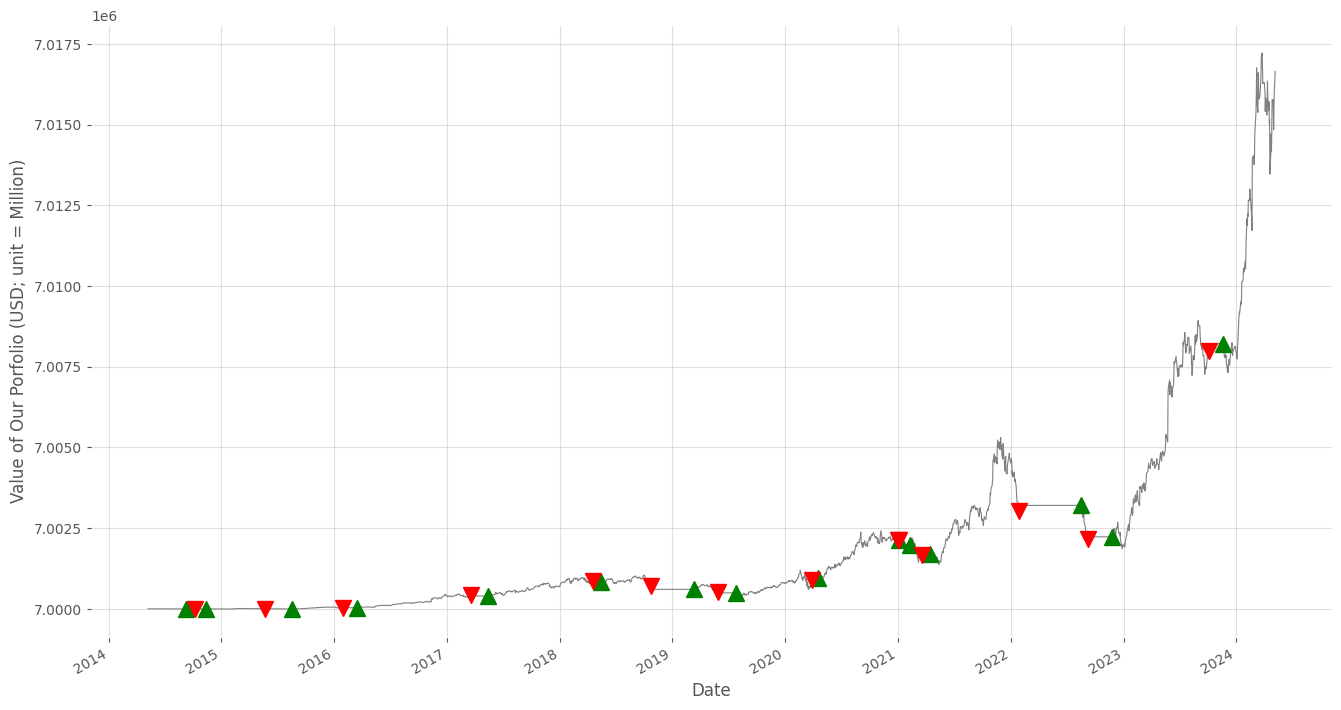

In [101]:
f=\
(
    plt
    .figure(figsize = [16, 9]
           )
)

ax =\
(
    f
    .add_subplot(111,
                 ylabel = "Value of Our Porfolio (USD; unit = Million)")
)

# Total Value of Our Portfolio

(
    portfolio
    ["total"]
    .plot(ax = ax,
          color = "grey",
          lw = 0.80)
)

# Signal (BUY)

(
    ax
    .plot(portfolio.loc[BUY_or_SELL.positions == 1.0].index,
          portfolio.total[BUY_or_SELL.positions == 1.0],
          "^",
          color = "green",
          markersize = 12)
)

# Signal (SELL)

(
    ax
    .plot(portfolio.loc[BUY_or_SELL.positions == -1.0].index,
          portfolio.total[BUY_or_SELL.positions == -1.0],
          "v",
          color = "red",
          markersize = 12)
)

> Now we have learned a trading strategy and backtested it. 

> Note that this is not the end of your trading strategy learning. You might want to improve your strategy. 

> Later you will learn how to improve the model, using machine learning algorithms such as KMeans, k-Nearest Neighbors (KNN), and Classification or Regression Trees.

> You might want to improve your trading strategy by working with multi-symbol portfolios. As we’ll discuss when assessing our moving average crossover strategy, incorporating only one company or symbol into your strategy rarely provides much information.

> You should use a risk management framework or event-driven backtesting to help mitigate the foresight (lookahead) bias.

## <a id = "p4">4.</a>  <font color = "green"> Performance Metrics </font>  [back to table of contents](#top)

### Performance Metrics: Assessing Our Moving Average Crossover Strategy

> Let’s quickly assess our simple trading strategy by utilizing what pandas offers:

- `Sharpe ratio`;
- `maximum drawdown`;
- `compound annual growth rate (CAGR)`

> Let’s start with the Sharpe ratio. Here, we won’t take the risk-free rate in estimating it.

> Please extend the original trading strategy with more data (from other companies), when using Sharpe ratio.

### Mathematical Definition of Sharpe Ratio

$$
    \begin{equation}
    \text{Sharpe Ratio} = \frac{\text{Expected Portfolio Return} - \text{Risk-Free Rate}}
    {\text{Porfolio Standard Deviation}}
    \end{equation}
$$

In [135]:
maang = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]

In [103]:
maang_prices =\
(
    yf
    .download(maang,
              start = dt.datetime(2014, 5, 9),
              end = dt.datetime(2025, 5, 8)
             )
    ["Close"]
)

[*********************100%***********************]  5 of 5 completed


In [104]:
maang_prices

Ticker,AAPL,AMZN,GOOG,META,NFLX
Date,,,,,
2014-05-09,18.390551,14.612000,25.689686,56.889294,46.935715
2014-05-12,18.619518,15.143000,26.243860,59.463428,49.349998
2014-05-13,18.648720,15.232000,26.400854,59.463428,49.591431
2014-05-14,18.652184,14.881000,26.081917,58.867096,50.268570
2014-05-15,18.493570,14.759500,25.751589,57.565125,49.169998
...,...,...,...,...,...
2025-05-01,212.799133,190.199997,162.449356,571.384460,1133.469971
2025-05-02,204.848587,189.979996,165.463043,596.158630,1156.489990
2025-05-05,198.404358,186.350006,165.702545,598.405396,1134.060059


### Daily Return of MAANG Stocks

In [105]:
daily_returns_MAANG =\
(
    maang_prices
    .pct_change()
)

In [106]:
daily_returns_MAANG = daily_returns_MAANG.fillna(0)

In [107]:
from lets_plot import *
LetsPlot.setup_html()

### One way to gauge volatility of returns: boxplot

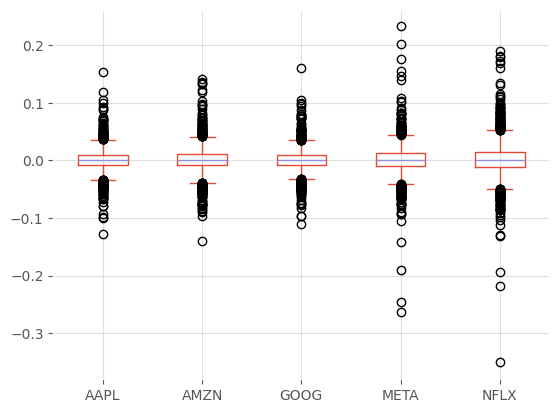

In [108]:
daily_returns_MAANG.plot(kind = "box")
plt.show()

## Calculating Mathematical Defition of Volatiliy with Python

In [109]:
non_annualized_volatility =\
(
    daily_returns_MAANG
    .rolling(252)
    .std()    
)

In [110]:
non_annualized_volatility

Ticker,AAPL,AMZN,GOOG,META,NFLX
Date,,,,,
2014-05-09,NaN,NaN,NaN,NaN,NaN
2014-05-12,NaN,NaN,NaN,NaN,NaN
2014-05-13,NaN,NaN,NaN,NaN,NaN
2014-05-14,NaN,NaN,NaN,NaN,NaN
2014-05-15,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2025-05-01,0.020502,0.021240,0.018703,0.022668,0.020430
2025-05-02,0.020609,0.021135,0.018698,0.022817,0.020424
2025-05-05,0.020705,0.021124,0.018695,0.022785,0.020474


In [111]:
annualized_volatility =\
(
    daily_returns_MAANG
    .rolling(252)
    .std()    
    *
    np.sqrt(252) # ANNUALIZED
)

In [112]:
annualized_volatility

Ticker,AAPL,AMZN,GOOG,META,NFLX
Date,,,,,
2014-05-09,NaN,NaN,NaN,NaN,NaN
2014-05-12,NaN,NaN,NaN,NaN,NaN
2014-05-13,NaN,NaN,NaN,NaN,NaN
2014-05-14,NaN,NaN,NaN,NaN,NaN
2014-05-15,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2025-05-01,0.325457,0.337167,0.296900,0.359842,0.324322
2025-05-02,0.327150,0.335504,0.296826,0.362211,0.324229
2025-05-05,0.328680,0.335327,0.296779,0.361694,0.325010


### Fat-tailed Nature of Stock as an asset class

In [113]:
import scipy.stats as stats

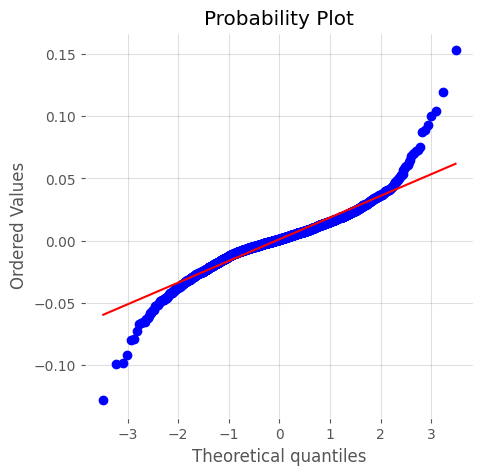

In [114]:
f = plt.figure(figsize = [5,5]
              )

ax = f.add_subplot(111)

(
    stats
    .probplot(daily_returns_MAANG["AAPL"],
              plot = ax,
              dist = "norm")
)

plt.show()

> Sharpe ratio is often compared to other stocks. Please extend the original trading strategy with more data (from other companies).

$$
    \begin{equation}
    \text{Sharpe Ratio} = \frac{\text{Average Daily Return}}{\text{Daily Standard Deviation}} \times
    \sqrt{252}
    \end{equation}
$$

In [115]:
portfolio.columns

Index(['nvda', 'our_holdings', 'our_cash', 'total', 'return'], dtype='object')

In [116]:
Sharpe =\
(
    (portfolio["return"].mean() / portfolio["return"].std()
    ) * np.sqrt(252)
)

In [117]:
Sharpe

np.float64(0.8494677747430067)

### Sharpen Our Financial Decision Making?

#### <mark>Scenario: Investment returning 7% per year for 25 years.</mark>

In [118]:
# !pip install numpy-financial

In [119]:
import numpy_financial as npf

### Step 1: Let's estimate future value of your investment
### <mark>NOTE that this does NOT mean the TRUE final value of your investment.</mark>

In [120]:
starting_capital = 5e4

In [121]:
starting_capital

50000.0

In [122]:
investment_future_value =\
(
    npf # fv() returns future value of your investment
    .fv(rate = 0.07,
        nper = 25,
        pmt = 0,
        pv = -starting_capital)
)

In [123]:
print("Our investment will return of a total $"
      + 
      str(round(investment_future_value, 1)
         )
      + 
      " in 25 years.")

Our investment will return of a total $271371.6 in 25 years.


### <mark>TEAM, we SHOULD take into account the deprecation of monetary value!</mark>

### Step 2: After adjusting for inflation of 3.5% per year for 25 years, what's the worth of our invesment.

In [124]:
discounted_value =\
(
    npf
    .pv(rate = 0.035, # inflation rate (average inflation rate over time) --> hyperbolic function
        nper = 25,
        pmt = 0,
        fv = investment_future_value
        )
)

In [125]:
print("After adjusting for inflation, our invesment in worth $"
      + 
     str(round(-discounted_value, 1)
        )
      + 
      " in today's dollars."
     )

After adjusting for inflation, our invesment in worth $114830.1 in today's dollars.


### Maximum Drawdown (MDD)

> Maximum drawdown is for measuring the largest single drop, from peak to bottom, in the value of a portfolio ahead of a new peak being achieved. The metric denotes the risk of a portfolio chosen according to a certain strategy.

In [126]:
window = 252

In [127]:
rolling_max =\
(
    nvda
    ["price"]
    .rolling(window = window,
             min_periods = 1)
    # .mean()
    .max()
)

In [128]:
daily_drawdown =\
(
    (nvda["price"] 
     / 
     rolling_max)
    - 1.0
)

# We are now calculating daily drawdown
# ==> how much closing price of each day has dropped from the rolling maximum price

* If the `value = 0`, the current daily closing price is the rolling maximum
* If the `value < 0`, it denotes the current daily closing price is below the rolling maximum

In [129]:
daily_drawdown # when is the maximum draw-down?

Date
2014-05-08    0.000000
2014-05-09   -0.024324
2014-05-12    0.000000
2014-05-13   -0.016146
2014-05-14   -0.025834
                ...   
2024-04-30   -0.090524
2024-05-01   -0.125903
2024-05-02   -0.096682
2024-05-03   -0.065399
2024-05-06   -0.030126
Name: price, Length: 2516, dtype: float64

In [130]:
max_daily_drawdown =\
(
    daily_drawdown # this is negative
    .rolling(window = window,
             min_periods = 1)
    .min() # lowest value
)

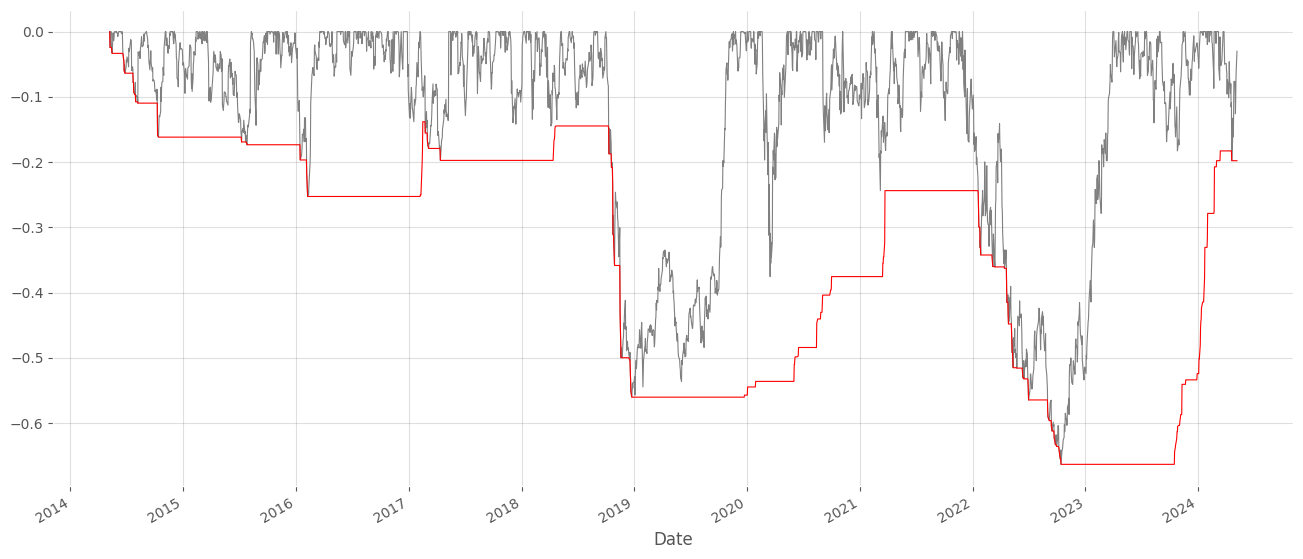

In [131]:
fig = plt.figure(figsize = [16, 7]
                )

daily_drawdown.plot(color = "grey",
                    lw = 0.80)

max_daily_drawdown.plot(color = "red",
                        lw = 0.80)

plt.show()

### Compound Annual Growth Rate (CAGR)

> CAGR gives us a constant rate of return over a time period. 

The rate tells you what you really have at the end of your investment period.

- First, let’s calculate CAGR by dividing the investment’s ending value (EV) by its beginning value (BV).
- Then, raise the result to the power of 1/n, where n is the number of periods.
- Subtract 1 from the result. This is the CAGR.

$$ CAGR = (EV/BV)^{1/n} - 1 $$

$$
    \text{CAGR} = \left( \frac{\text{End Value}}{\text{Start}} \right)^{\frac{365}
    {\text{Total Days}}
    } - 1
$$

In [132]:
days =\
(
    (nvda.index[-1] 
     -
     nvda.index[0]
    ).days
)

days

3651

In [133]:
CAGR =\
(
    (nvda["price"][-1] 
     / 
     nvda["price"][0]
    ) ** (365.0 / days)   
) - 1

In [134]:
CAGR

np.float64(0.7068886583970717)

#### Cautionary Tales

> Beyond testing a trading strategy, backtesting tests it on relevant historical data to see if it is a viable strategy before you make any moves. With backtesting, you can simulate and analyze the risk and profitability of trading with a specific strategy over a period of time.

But keep in mind that backtesting has some limitations.

- There could be external events, such as market regime shifts, which are regulatory changes or macroeconomic events, which will affect your backtesting.
- Liquidity constraints, such as a ban on short sales, could also influence your backtesting.
- You could overfit a model (optimization bias) when you ignore strategy rules because you think it’s better like that (interference), or you could accidentally introduce information into past data (foresight bias).

## <a id = "p5">5.</a>  <font color = "green"> What We Learned... </font>  [back to table of contents](#top)

> Team, the current lecture notes will serve as valuable reference materials in the field—your playbook and field manual. As you learn, please make active use of Markdown cells to document your insights and understanding. This practice will not only help you fully absorb the material but also increase its applicability in real-world contexts. 🙂

    - Learning Pointer 1.

    - Learning Pointer 2.

    - Learning Pointer 3.

> `Thank you for working with the script, Team 👍`